In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

In [2]:
go_biological_processes = pd.read_csv("../results/functional_enrichment/up_regulated/enrichment_GO_Biological_Process_2018.tsv", sep='\t')
go_cellular_components = pd.read_csv("../results/functional_enrichment/up_regulated/enrichment_GO_Cellular_Component_2018.tsv", sep='\t')
go_molecular_functions = pd.read_csv("../results/functional_enrichment/up_regulated/enrichment_GO_Molecular_Function_2018.tsv", sep='\t')
kegg_pathways = pd.read_csv("../results/functional_enrichment/up_regulated/enrichment_KEGG_2018.tsv", sep='\t')

go_biological_processes_down = pd.read_csv("../results/functional_enrichment/down_regulated/enrichment_GO_Biological_Process_2018.tsv", sep='\t')
go_cellular_components_down = pd.read_csv("../results/functional_enrichment/down_regulated/enrichment_GO_Cellular_Component_2018.tsv", sep='\t')
go_molecular_functions_down = pd.read_csv("../results/functional_enrichment/down_regulated/enrichment_GO_Molecular_Function_2018.tsv", sep='\t')
kegg_pathways_down = pd.read_csv("../results/functional_enrichment/down_regulated/enrichment_KEGG_2018.tsv", sep='\t')

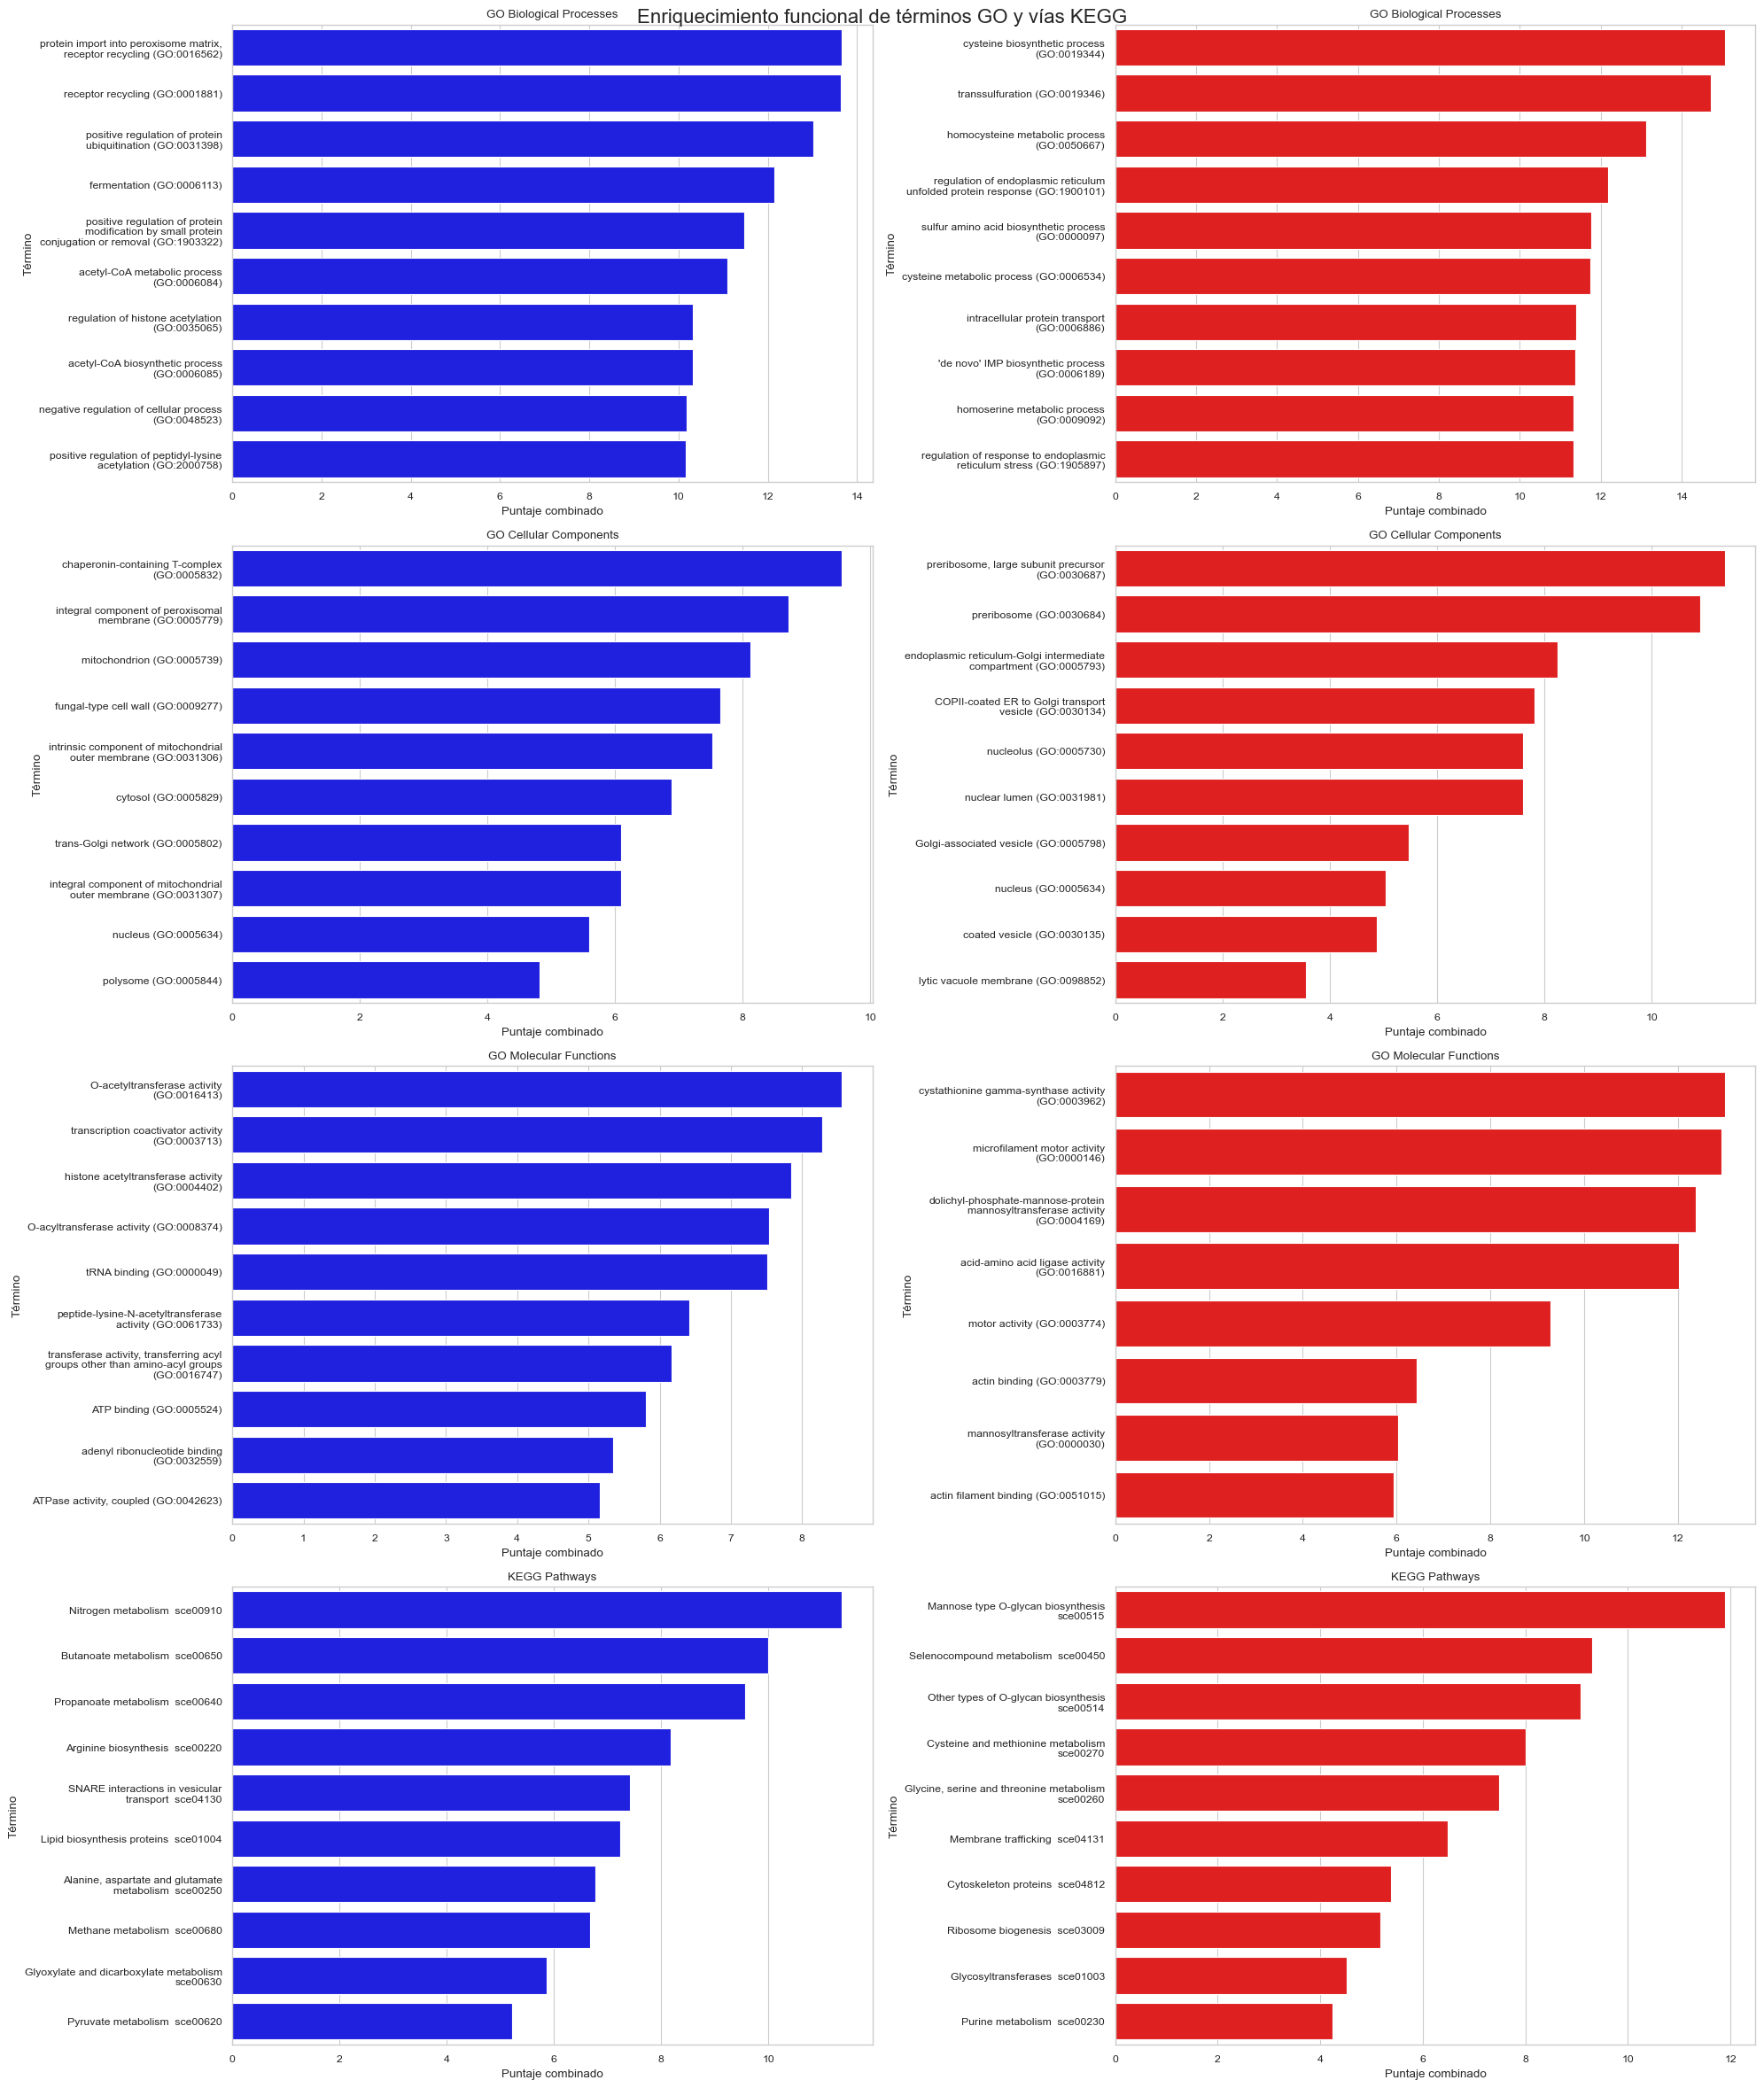

In [3]:
annotations = {
    "up" : {
        "GO Biological Processes": go_biological_processes,
        "GO Cellular Components": go_cellular_components,
        "GO Molecular Functions": go_molecular_functions,
        "KEGG Pathways": kegg_pathways
    },
    "down" : {
        "GO Biological Processes": go_biological_processes_down,
        "GO Cellular Components": go_cellular_components_down,
        "GO Molecular Functions": go_molecular_functions_down,
        "KEGG Pathways": kegg_pathways_down
    }
}
sns.set_style("whitegrid")
sns.set_context("paper")
row = 1
height_per_bar = 0.3
plt.figure(figsize=(20, 80 * height_per_bar))
for name, df, df_down in zip(annotations["up"].keys(), annotations["up"].values(), annotations["down"].values()):
    df["Term"] = df["Term"].apply(lambda x: "\n".join(textwrap.wrap(x, 40)))
    df_down["Term"] = df_down["Term"].apply(lambda x: "\n".join(textwrap.wrap(x, 40)))
    plt.subplot(4, 2, row+1)
    sns.barplot(df.head(10), x="Combined Score", y="Term", color="red")
    plt.title(name)
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")
    plt.subplot(4, 2, row)
    sns.barplot(df_down.head(10), x="Combined Score", y="Term", color="blue")
    plt.title(name)
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")
    row += 2


plt.suptitle("Enriquecimiento funcional de términos GO y vías KEGG", fontsize=16)
plt.tight_layout()
plt.show()

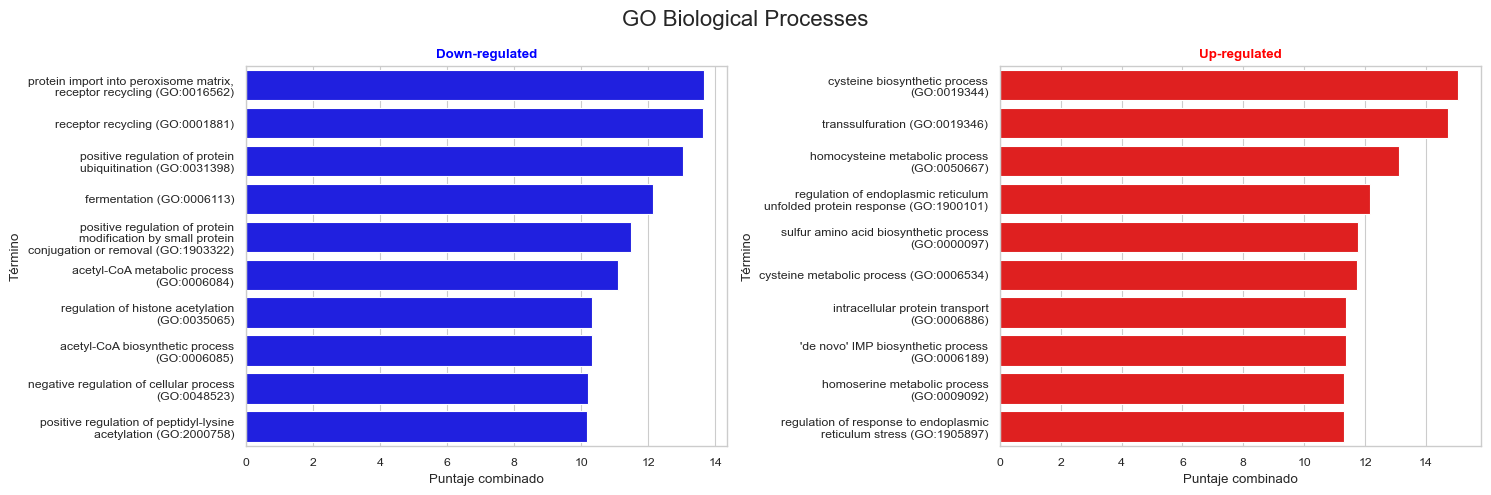

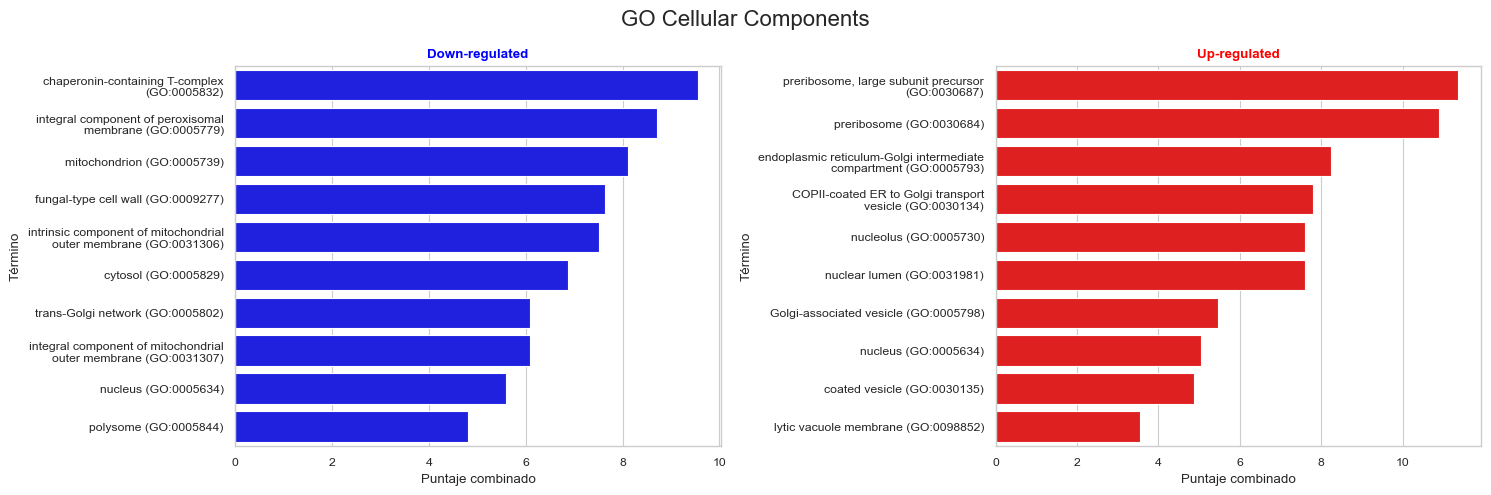

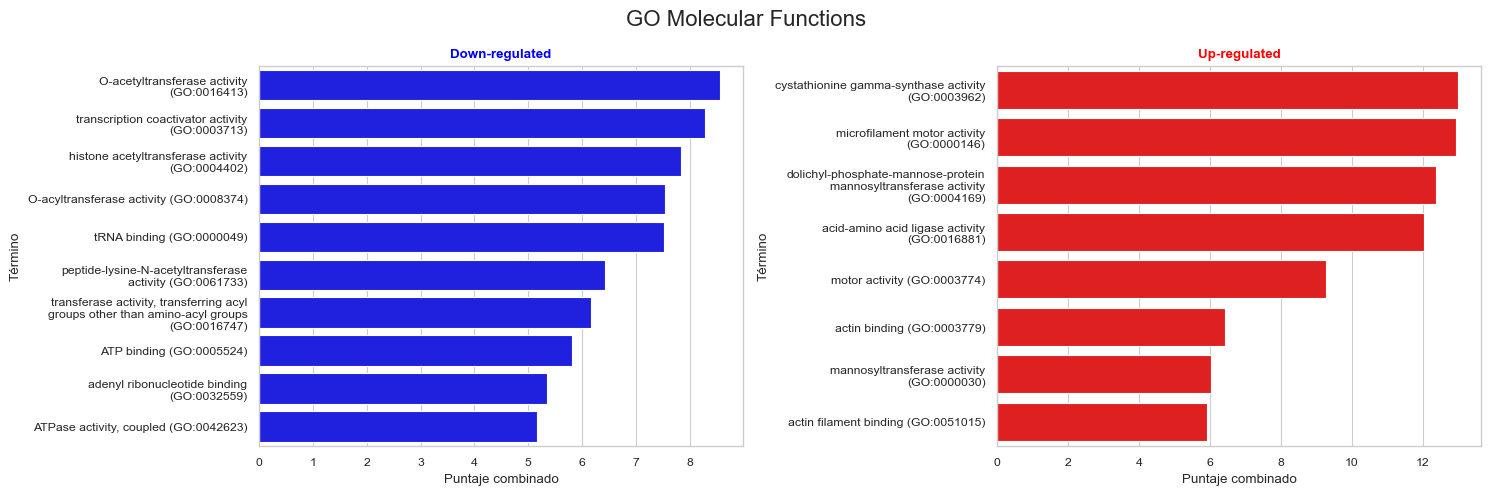

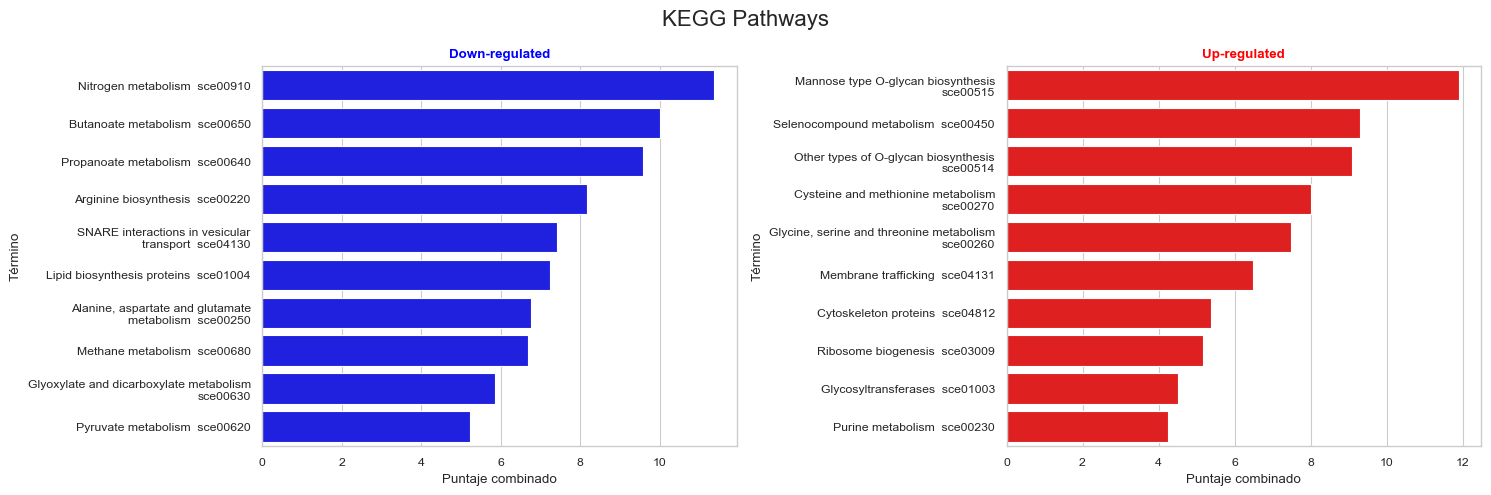

In [4]:
annotations = {
    "up" : {
        "GO Biological Processes": go_biological_processes,
        "GO Cellular Components": go_cellular_components,
        "GO Molecular Functions": go_molecular_functions,
        "KEGG Pathways": kegg_pathways
    },
    "down" : {
        "GO Biological Processes": go_biological_processes_down,
        "GO Cellular Components": go_cellular_components_down,
        "GO Molecular Functions": go_molecular_functions_down,
        "KEGG Pathways": kegg_pathways_down
    }
}
sns.set_style("whitegrid")
sns.set_context("paper")

height_per_bar = 0.25

for name, df, df_down in zip(annotations["up"].keys(), annotations["up"].values(), annotations["down"].values()):
    plt.figure(figsize=(15, 20 * height_per_bar))

    df["Term"] = df["Term"].apply(lambda x: "\n".join(textwrap.wrap(x, 40)))
    df_down["Term"] = df_down["Term"].apply(lambda x: "\n".join(textwrap.wrap(x, 40)))
    plt.subplot(1, 2, 2)
    sns.barplot(df.head(10), x="Combined Score", y="Term", color="red")
    plt.title("Up-regulated", color="red", weight="bold")
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")
    plt.subplot(1, 2, 1)
    sns.barplot(df_down.head(10), x="Combined Score", y="Term", color="blue")
    plt.title("Down-regulated", color="blue", weight="bold")
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")



    plt.suptitle(name, fontsize=16)
    plt.tight_layout()
    plt.show()

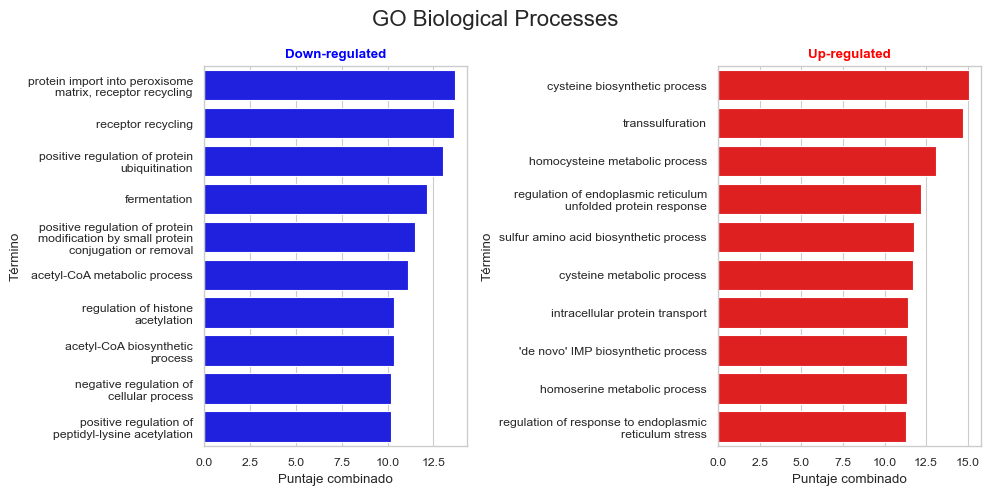

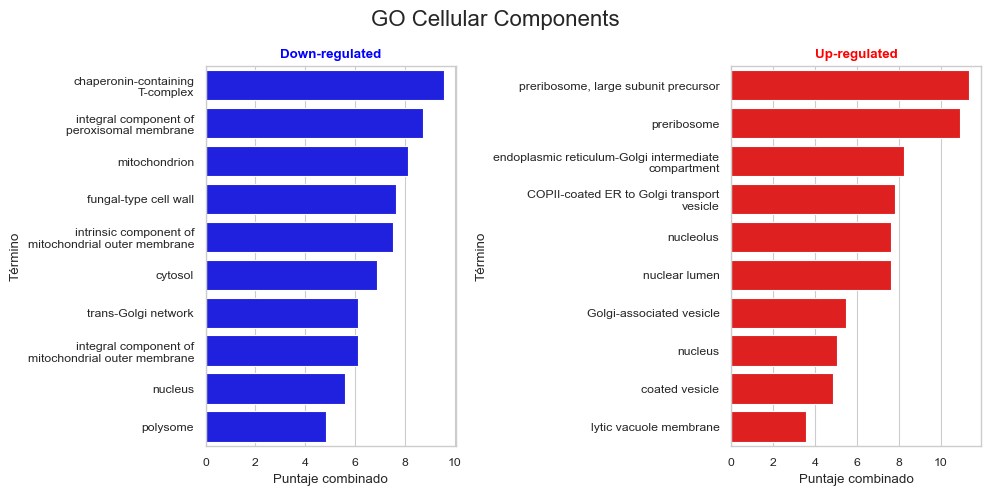

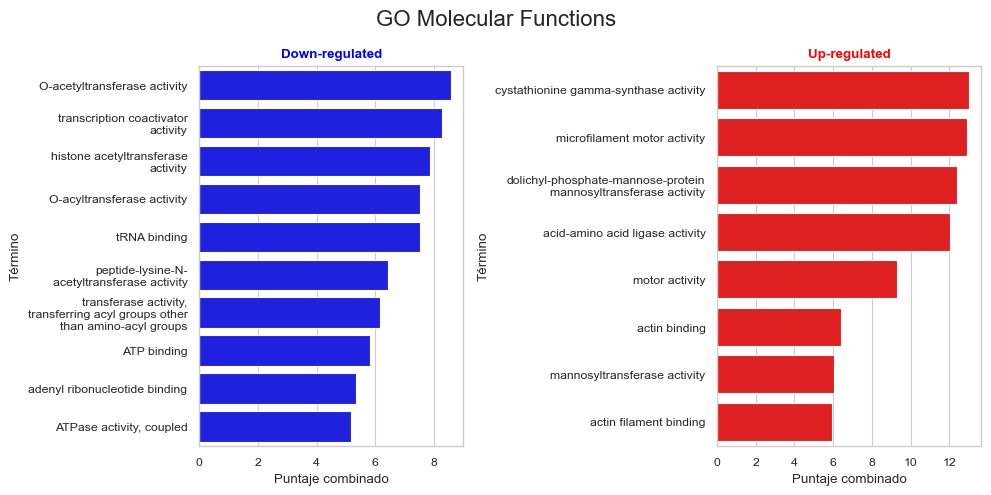

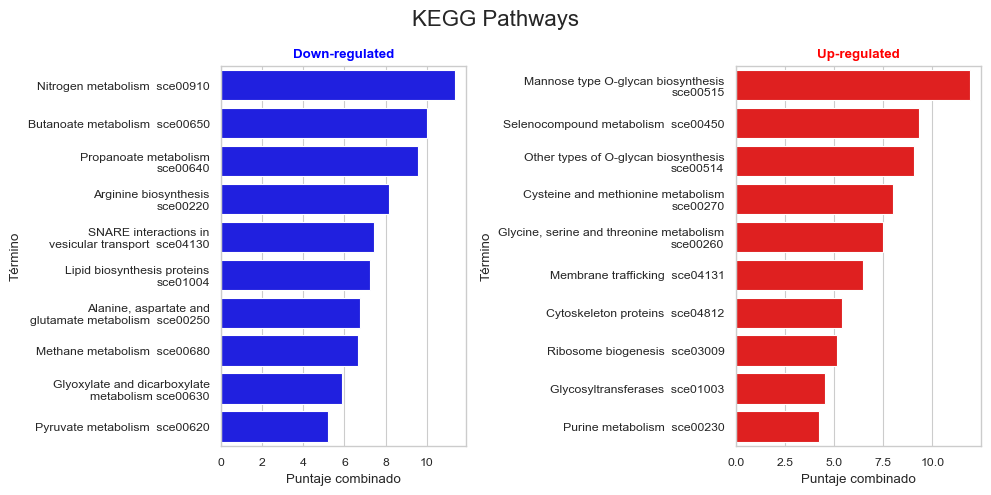

In [5]:
import re

def extract_go_and_term(term):
    # Buscar patrón GO:#######
    match = re.search(r'\(GO:\d+\)', term)
    if match:
        go_code = match.group(0).strip("()")  # Quita paréntesis
        # El término sin el código GO y sin paréntesis
        term_clean = term.replace(match.group(0), '').strip()
        return pd.Series([go_code, term_clean])
    else:
        # Si no encuentra código GO, devuelve None para GO y el término original
        return pd.Series([None, term])

for name, df, df_down in zip(annotations["up"].keys(), annotations["up"].values(), annotations["down"].values()):
    plt.figure(figsize=(10, 20 * height_per_bar))

    # Extraer GO y término limpio para UP
    df[["GO", "Term_clean"]] = df["Term"].apply(extract_go_and_term)
    df["Term_clean"] = df["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(str(x), 40)))

    # Extraer GO y término limpio para DOWN
    df_down[["GO", "Term_clean"]] = df_down["Term"].apply(extract_go_and_term)
    df_down["Term_clean"] = df_down["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(str(x), 30)))

    # Plot DOWN
    plt.subplot(1, 2, 1)
    ax1 = sns.barplot(data=df_down.head(10), x="Combined Score", y="Term_clean", color="blue")
    plt.title("Down-regulated", color="blue", weight="bold")
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")


    # Plot UP
    plt.subplot(1, 2, 2)
    ax2 = sns.barplot(data=df.head(10), x="Combined Score", y="Term_clean", color="red")
    plt.title("Up-regulated", color="red", weight="bold")
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")


    plt.suptitle(name, fontsize=16)
    plt.tight_layout()
    plt.show()


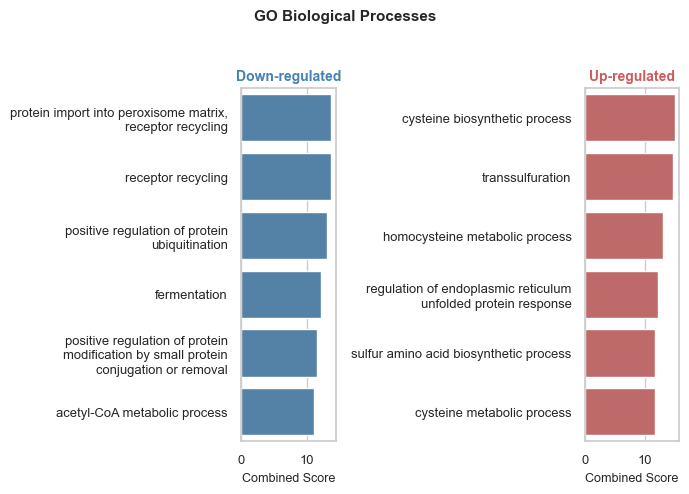

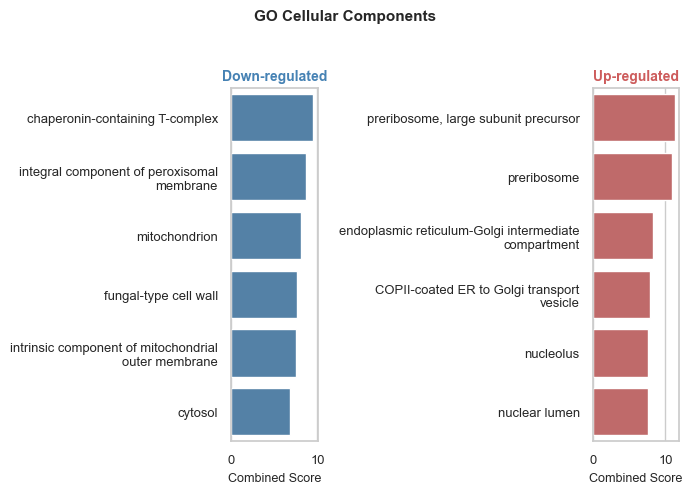

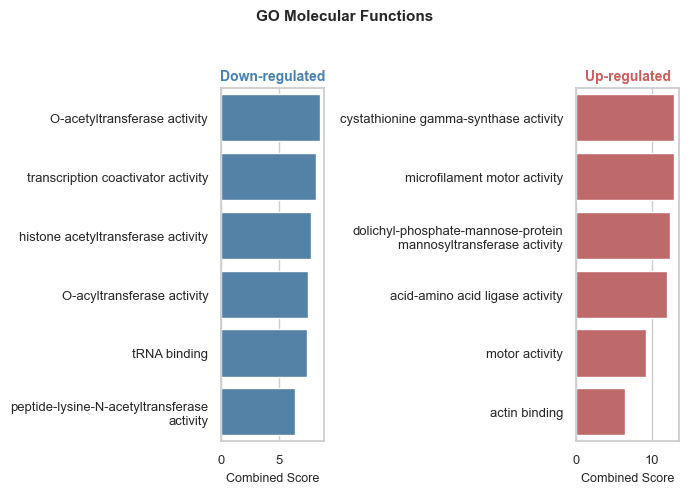

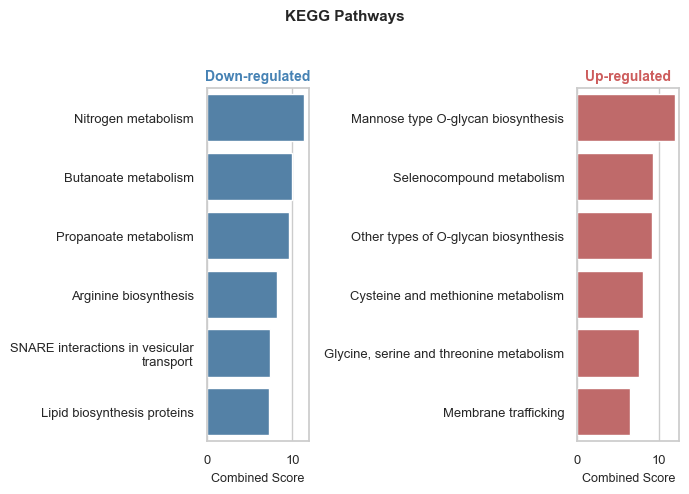

In [6]:
import re
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_go_and_term(term):
    match = re.search(r'\(GO:\d+\)', term)
    match_sce = re.search(r'sce\d+', term)
    if match:
        go_code = match.group(0).strip("()")
        term_clean = term.replace(match.group(0), '').strip()
        return pd.Series([go_code, term_clean])
    if match_sce:
        sce_code = match_sce.group(0).strip("()")
        term_clean = term.replace(match_sce.group(0), '').strip()
        return pd.Series([sce_code, term_clean])
    else:
        return pd.Series([None, term])


def add_labels_inside(ax):
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width - 0.05 * width,
                    p.get_y() + p.get_height() / 2,
                    f"{width:.1f}",
                    ha='right', va='center',
                    color='white', fontsize=7, weight='bold')

sns.set(style="whitegrid", font_scale=0.85)  # Más compacto para figuras de publicación

for name, df, df_down in zip(annotations["up"].keys(), annotations["up"].values(), annotations["down"].values()):
    plt.figure(figsize=(7, 5))  # Tamaño ideal para una figura de dos columnas en un paper

    # Procesar términos
    df[["GO", "Term_clean"]] = df["Term"].apply(extract_go_and_term)

    df_down[["GO", "Term_clean"]] = df_down["Term"].apply(extract_go_and_term)

    df["Term_clean"] = df["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(str(x), 40)))
    df_down["Term_clean"] = df_down["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(str(x), 40)))

    # DOWN
    plt.subplot(1, 2, 1)
    ax1 = sns.barplot(data=df_down.head(6), x="Combined Score", y="Term_clean", color="steelblue")
    plt.title("Down-regulated", fontsize=10, color="steelblue", weight="bold")
    plt.xlabel("Combined Score", fontsize=9)
    plt.ylabel("")  # sin redundancia

    # UP
    plt.subplot(1, 2, 2)
    ax2 = sns.barplot(data=df.head(6), x="Combined Score", y="Term_clean", color="indianred")
    plt.title("Up-regulated", fontsize=10, color="indianred", weight="bold")
    plt.xlabel("Combined Score", fontsize=9)
    plt.ylabel("")

    plt.suptitle(name, fontsize=11, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{name}_barplot.png", dpi=300, bbox_inches='tight')  # Para paper
    plt.show()


In [7]:
go_biological_processes_extended = pd.read_csv("../results/functional_enrichment/extended_analysis/enrichment_GO_Biological_Process_2018.tsv", sep='\t')
go_cellular_components_extended = pd.read_csv("../results/functional_enrichment/extended_analysis/enrichment_GO_Cellular_Component_2018.tsv", sep='\t')
go_molecular_functions_extended = pd.read_csv("../results/functional_enrichment/extended_analysis/enrichment_GO_Molecular_Function_2018.tsv", sep='\t')
kegg_pathways_extended = pd.read_csv("../results/functional_enrichment/extended_analysis/enrichment_KEGG_2018.tsv", sep='\t')

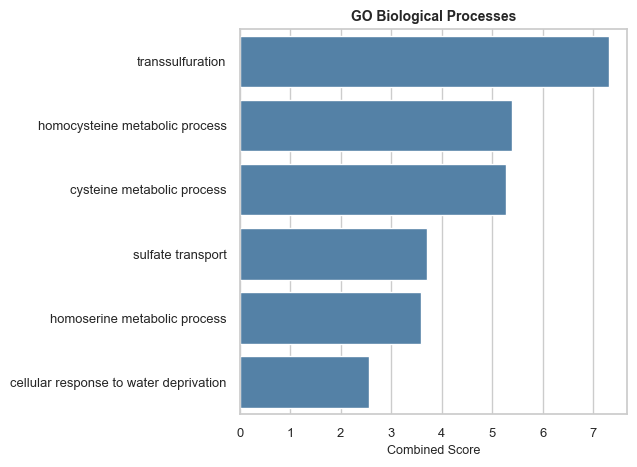

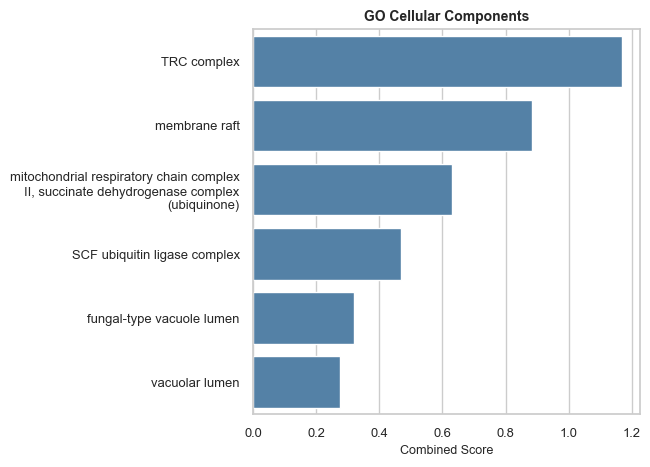

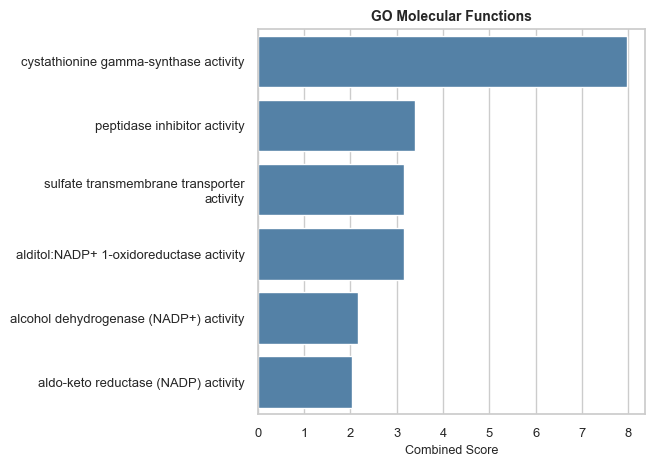

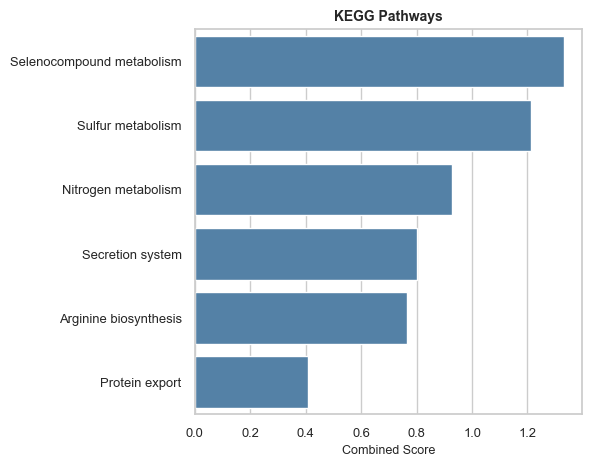

In [11]:
annotations_extended = {
    "GO Biological Processes": go_biological_processes_extended,
    "GO Cellular Components": go_cellular_components_extended,
    "GO Molecular Functions": go_molecular_functions_extended,
    "KEGG Pathways": kegg_pathways_extended
}

for name, df in zip(annotations_extended.keys(), annotations_extended.values()):
    plt.figure(figsize=(5, 5))  # Tamaño ideal para una figura de dos columnas en un paper

    df[["GO", "Term_clean"]] = df["Term"].apply(extract_go_and_term)

    df["Term_clean"] = df["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(str(x), 40)))

    df.drop(df[df["Term_clean"] == "Function unknown"].index, inplace=True)  # Eliminar filas con puntaje negativo


    ax1 = sns.barplot(data=df.head(6), x="Combined Score", y="Term_clean", color="steelblue")
    plt.xlabel("Combined Score", fontsize=9)
    plt.title(name, fontsize=10, weight="bold")
    plt.ylabel("")  # sin redundancia
    plt.savefig(f"{name}_extended_barplot.png", dpi=1000, bbox_inches='tight')  # Para paper
